In [110]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [111]:
#Create Environment (creates world)
env = gym.make("CartPole-v1")

In [112]:
#Reset Environment (start new episodes & return state = 4 values(cart position, velocity, angle, angular velocity))
state, _ = env.reset()
print("Initial State:", state)

Initial State: [-0.01227924 -0.0347608  -0.03674474  0.02438194]


In [113]:
#Take Random Actions (First interaction)
for _ in range(5):
    action = env.action_space.sample()
    next_state, reward, done, truncated, _ = env.step(action)
    
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward:", reward)
    print("Done:", done)
    print("------")

Action: 1
Next State: [-0.01297446  0.1608683  -0.0362571  -0.27966416]
Reward: 1.0
Done: False
------
Action: 1
Next State: [-0.00975709  0.3564882  -0.04185038 -0.58355844]
Reward: 1.0
Done: False
------
Action: 1
Next State: [-0.00262733  0.5521707  -0.05352155 -0.8891256 ]
Reward: 1.0
Done: False
------
Action: 0
Next State: [ 0.00841608  0.35781428 -0.07130406 -0.6137363 ]
Reward: 1.0
Done: False
------
Action: 1
Next State: [ 0.01557237  0.5538564  -0.08357879 -0.9279978 ]
Reward: 1.0
Done: False
------


In [114]:
#Run One Full Episode
state, _ = env.reset()

total_reward = 0

for step in range(1000):
    action = env.action_space.sample()
    state, reward, done, truncated, _ = env.step(action)
    
    total_reward += reward
    
    if done or truncated:
        break

print("Total Reward:", total_reward)

Total Reward: 17.0


In [115]:
#Run Multiple Episodes
episodes = 20
rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    
    for step in range(1000):
        action = env.action_space.sample()
        state, reward, done, truncated, _ = env.step(action)
        
        total_reward += reward
        
        if done or truncated:
            break
    
    rewards.append(total_reward)

print(rewards)

[14.0, 72.0, 12.0, 16.0, 27.0, 18.0, 32.0, 17.0, 17.0, 15.0, 15.0, 18.0, 12.0, 13.0, 19.0, 14.0, 21.0, 17.0, 31.0, 18.0]


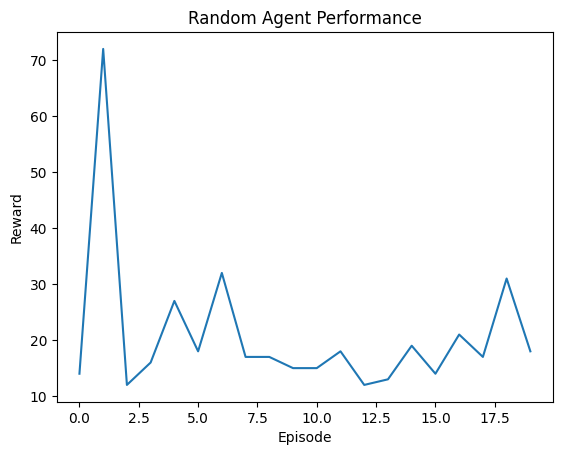

In [116]:
#Results
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random Agent Performance")
plt.show()

In [117]:
#Discretization (convert values to bins)

# Number of buckets for each state variable
n_bins = (10, 10, 10, 10)

# Define upper and lower bounds
upper_bounds = [2.4, 3.0, 0.5, 2.0]
lower_bounds = [-2.4, -3.0, -0.5, -2.0]

In [118]:
#Discretization Function
def discretize(state):
    ratios = [(state[i] - lower_bounds[i]) / (upper_bounds[i] - lower_bounds[i]) for i in range(len(state))]
    
    new_state = [int(round((n_bins[i] - 1) * ratios[i])) for i in range(len(state))]
    
    new_state = [min(n_bins[i] - 1, max(0, new_state[i])) for i in range(len(state))]
    
    return tuple(new_state)

In [119]:
#Test Discretization

state, _ = env.reset()

discrete_state = discretize(state)

print("Original:", state)
print("Discrete:", discrete_state)

Original: [ 0.0132741   0.01615028  0.00166271 -0.04492089]
Discrete: (5, 5, 5, 4)


In [120]:
#Create Q-table
q_table = np.zeros(n_bins + (env.action_space.n,))

In [121]:
#Hyperparameters
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 5000

In [122]:
#Q-learning Training Loop
rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    discrete_state = discretize(state)
    
    total_reward = 0
    
    for step in range(1000):
        
        # ε-greedy policy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[discrete_state])
        
        next_state, reward, done, truncated, _ = env.step(action)
        next_discrete_state = discretize(next_state)
        
        # Q-learning update
        best_future_q = np.max(q_table[next_discrete_state])
        
        q_table[discrete_state + (action,)] += learning_rate * (
            reward + discount_factor * best_future_q - q_table[discrete_state + (action,)]
        )
        
        discrete_state = next_discrete_state
        total_reward += reward
        
        if done or truncated:
            break
    
    # decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    rewards.append(total_reward)

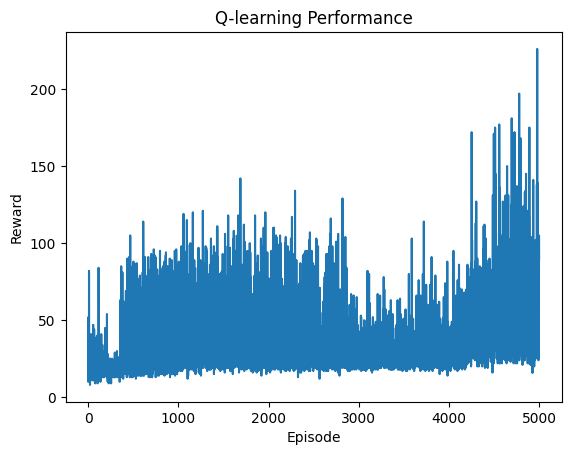

In [123]:
#Plot Learning

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-learning Performance")
plt.show()

In [124]:
#Moving Average Function
def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

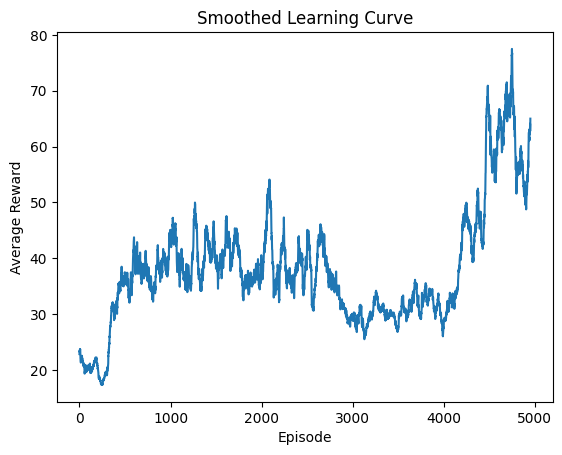

In [125]:
#Plot Smoothed Curve
smoothed_rewards = moving_average(rewards)

plt.plot(smoothed_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Smoothed Learning Curve")
plt.show()

In [126]:
#Better Discretization (Improved Bins)
n_bins = (8, 8, 12, 12)  # more focus on angle
upper_bounds = [2.4, 3.0, 0.418, 2.0]
lower_bounds = [-2.4, -3.0, -0.418, -2.0]

In [127]:
#Hyperparameters
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.999
min_epsilon = 0.01
episodes = 5000

In [128]:
for episode in range(episodes):
    state, _ = env.reset()
    discrete_state = discretize(state)
    
    total_reward = 0
    
    for step in range(1000):
        
        # ε-greedy policy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[discrete_state])
        
        next_state, reward, done, truncated, _ = env.step(action)
        next_discrete_state = discretize(next_state)
        
        # Q-learning update
        q_table = np.zeros(n_bins + (env.action_space.n,))
        
        q_table[discrete_state + (action,)] += learning_rate * (
            reward + discount_factor * best_future_q - q_table[discrete_state + (action,)]
        )
        
        discrete_state = next_discrete_state
        total_reward += reward
        
        if done or truncated:
            break
    
    rewards.append(total_reward)
    
    
    if episode % 100 == 0:
        print(f"Episode: {episode}, Avg Reward: {np.mean(rewards[-100:])}, Epsilon: {epsilon:.3f}")
    
    # decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

Episode: 0, Avg Reward: 56.75, Epsilon: 1.000
Episode: 100, Avg Reward: 22.99, Epsilon: 0.905
Episode: 200, Avg Reward: 21.37, Epsilon: 0.819
Episode: 300, Avg Reward: 20.35, Epsilon: 0.741
Episode: 400, Avg Reward: 19.0, Epsilon: 0.670
Episode: 500, Avg Reward: 16.03, Epsilon: 0.606
Episode: 600, Avg Reward: 15.73, Epsilon: 0.549
Episode: 700, Avg Reward: 14.11, Epsilon: 0.496
Episode: 800, Avg Reward: 14.11, Epsilon: 0.449
Episode: 900, Avg Reward: 13.32, Epsilon: 0.406
Episode: 1000, Avg Reward: 12.03, Epsilon: 0.368
Episode: 1100, Avg Reward: 12.01, Epsilon: 0.333
Episode: 1200, Avg Reward: 11.83, Epsilon: 0.301
Episode: 1300, Avg Reward: 11.77, Epsilon: 0.272
Episode: 1400, Avg Reward: 10.96, Epsilon: 0.246
Episode: 1500, Avg Reward: 11.06, Epsilon: 0.223
Episode: 1600, Avg Reward: 10.84, Epsilon: 0.202
Episode: 1700, Avg Reward: 10.5, Epsilon: 0.183
Episode: 1800, Avg Reward: 10.43, Epsilon: 0.165
Episode: 1900, Avg Reward: 10.49, Epsilon: 0.149
Episode: 2000, Avg Reward: 10.19, 

In [129]:
print("Average Reward:", evaluate_agent())

Average Reward: 9.0


In [130]:
#Create Render ENvironment
env_render = gym.make("CartPole-v1", render_mode="human")

In [131]:
import subprocess
import sys

#Run trained Agent
subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium[classic-control]"])
discrete_state = discretize(state)

total_reward = 0

for step in range(1000):
    
    # No exploration → pure learned policy
    action = np.argmax(q_table[discrete_state])
    
    state, _ = env_render.reset()
    discrete_state = discretize(state)
    
    total_reward += reward
    
    if done or truncated:
        break

print("Total Reward:", total_reward)

env_render.close()

Total Reward: 1.0


In [132]:
#Record Video 
from gymnasium.wrappers import RecordVideo

state, _ = env.reset()

env_video = RecordVideo(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda x: True
)

In [133]:
#Run and save video
state, _ = env_video.reset()
discrete_state = discretize(state)

for step in range(1000):
    action = np.argmax(q_table[discrete_state])
    
    state, reward, done, truncated, _ = env_video.step(action)
    discrete_state = discretize(state)
    
    if done or truncated:
        break

env_video.close()

Apply DQN 

In [134]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

In [135]:
#Environment Setup
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]   # 4
action_size = env.action_space.n              # 2

print(state_size, action_size)

4 2


In [136]:
#Build Neural Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        
        self.fc1 = nn.Linear(state_size, 24)
        self.fc2 = nn.Linear(24, 24)
        self.fc3 = nn.Linear(24, action_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [137]:
#Initialize Model
model = DQN(state_size, action_size)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [138]:
#Replay Memory
memory = deque(maxlen=2000)

In [139]:
#Store Experience
def store_experience(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

In [140]:
#Action Selection
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return random.randrange(action_size)
    
    state_tensor = torch.FloatTensor(state)
    q_values = model(state_tensor)
    
    return torch.argmax(q_values).item()

In [141]:
#Training step
def train_model(batch_size=32):
    if len(memory) < batch_size:
        return
    
    batch = random.sample(memory, batch_size)
    
    states, actions, rewards, next_states, dones = zip(*batch)
    
    states = torch.FloatTensor(states)
    next_states = torch.FloatTensor(next_states)
    actions = torch.LongTensor(actions)
    rewards = torch.FloatTensor(rewards)
    dones = torch.FloatTensor(dones)
    
    # Current Q
    q_values = model(states)
    current_q = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
    
    # Target Q (using target network 🔥)
    next_q = target_model(next_states).max(1)[0]
    target_q = rewards + (1 - dones) * 0.99 * next_q
    
    loss = loss_fn(current_q, target_q.detach())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [142]:
def update_target():
    target_model.load_state_dict(model.state_dict())

In [143]:
target_model = DQN(state_size, action_size)
target_model.load_state_dict(model.state_dict())
target_model.eval()

DQN(
  (fc1): Linear(in_features=4, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=24, bias=True)
  (fc3): Linear(in_features=24, out_features=2, bias=True)
)

In [144]:
#Full training loop
episodes = 500
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    
    for step in range(1000):
        
        action = choose_action(state, epsilon)
        
        next_state, reward, done, truncated, _ = env.step(action)
        
        store_experience(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        
        train_model()
        
        if done or truncated:
            break
    
    rewards.append(total_reward)
    
    # update target network every 10 episodes
    if episode % 10 == 0:
        update_target()
    
    # decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    # logging
    if episode % 10 == 0:
        print(f"Episode: {episode}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

Episode: 0, Reward: 32.0, Epsilon: 0.995
Episode: 10, Reward: 17.0, Epsilon: 0.946
Episode: 20, Reward: 21.0, Epsilon: 0.900
Episode: 30, Reward: 25.0, Epsilon: 0.856
Episode: 40, Reward: 14.0, Epsilon: 0.814
Episode: 50, Reward: 33.0, Epsilon: 0.774
Episode: 60, Reward: 17.0, Epsilon: 0.737
Episode: 70, Reward: 66.0, Epsilon: 0.701
Episode: 80, Reward: 22.0, Epsilon: 0.666
Episode: 90, Reward: 51.0, Epsilon: 0.634
Episode: 100, Reward: 126.0, Epsilon: 0.603
Episode: 110, Reward: 11.0, Epsilon: 0.573
Episode: 120, Reward: 89.0, Epsilon: 0.545
Episode: 130, Reward: 78.0, Epsilon: 0.519
Episode: 140, Reward: 91.0, Epsilon: 0.493
Episode: 150, Reward: 134.0, Epsilon: 0.469
Episode: 160, Reward: 63.0, Epsilon: 0.446
Episode: 170, Reward: 126.0, Epsilon: 0.424
Episode: 180, Reward: 16.0, Epsilon: 0.404
Episode: 190, Reward: 10.0, Epsilon: 0.384
Episode: 200, Reward: 114.0, Epsilon: 0.365
Episode: 210, Reward: 123.0, Epsilon: 0.347
Episode: 220, Reward: 109.0, Epsilon: 0.330
Episode: 230, Re

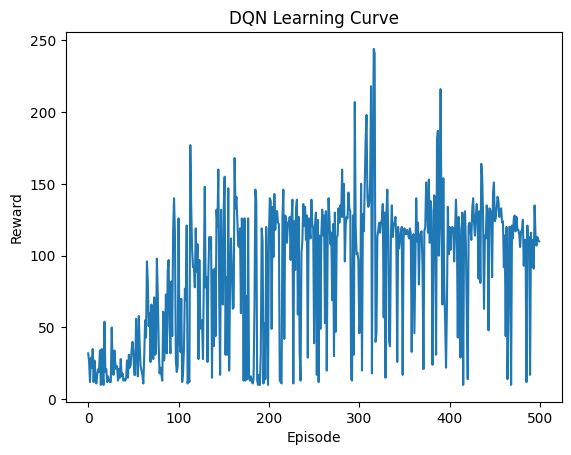

In [145]:
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Learning Curve")
plt.show()

In [146]:
def evaluate_dqn(episodes=10):
    scores = []
    
    for _ in range(episodes):
        state, _ = env.reset()
        total = 0
        
        for _ in range(1000):
            state_tensor = torch.FloatTensor(state)
            action = torch.argmax(model(state_tensor)).item()
            
            state, reward, done, truncated, _ = env.step(action)
            total += reward
            
            if done or truncated:
                break
        
        scores.append(total)
    
    return np.mean(scores)

print("Average Score:", evaluate_dqn())

Average Score: 111.6


In [147]:
action = torch.argmax(model(torch.FloatTensor(state))).item()